In [39]:
import pandas as pd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import NODATAVALUE, Predictors
from catboost import CatBoostClassifier
from pathlib import Path
import json 
from worldcereal_cop4geoglam.datasets import Cop4GeoLabelledDataset
from torch.utils.data import DataLoader
import numpy as np
import torch
import matplotlib.pyplot as plt

In [67]:
def get_timeseries_dates(start_date, end_date):
    # Truncate to month precision (year and month only, day is dropped)
    start_month = np.datetime64(start_date, "M")
    end_month = np.datetime64(end_date, "M")
    num_timesteps = (end_month - start_month).astype(int) + 1

    # generate date vector based on the number of timesteps
    date_vector = start_month + np.arange(num_timesteps, dtype="timedelta64[M]")

    # generate day, month and year vectors with numpy operations
    days = np.ones(len(date_vector), dtype=int)
    months = (date_vector.astype("datetime64[M]").astype(int) % 12) + 1
    years = (date_vector.astype("datetime64[Y]").astype(int)) + 1970
    dates = [f"{y:04d}-{m:02d}-{d:02d}" for y, m, d in zip(years, months, days)]
    return dates

def _apply_band_scaling(array: np.array, bandname: str) -> np.array:
    BANDS = {
        "S2-L2A": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
        "S1-SIGMA0": ["VV", "VH"],
        "DEM": ["slope", "elevation"],
        "AGERA5": ["PRECIP", "TMEAN"],
    }

    idx_valid = array != NODATAVALUE
    array = array.astype(np.float32)

    # No scaling for DEM bands
    if bandname in BANDS["DEM"]:
        pass
    # Divide by 10000 for S2 bands
    elif bandname.startswith("S2-L2A"):
        array[idx_valid] = array[idx_valid] / 10000
    # Convert to dB for S1 bands
    elif bandname.startswith("S1-SIGMA0"):
        idx_valid = idx_valid & (array > 0)
        array[idx_valid] = 20 * np.log10(array[idx_valid]) - 83
    # Scale meteo bands by factor 100
    elif bandname.startswith("AGERA5"):
        array[idx_valid] = array[idx_valid] / 100
    else:
        raise ValueError(f"Unsupported band name {bandname}")

    return array

def compute_ndvi(df):
    b4_ts_columns = [col for col in df.columns if 'B04' in col]
    b8_ts_columns = [col for col in df.columns if 'B08' in col]
    b4 = _apply_band_scaling(df[b4_ts_columns].values, "S2-L2A-B04")
    b8 = _apply_band_scaling(df[b8_ts_columns].values, "S2-L2A-B08")
    ndvi = (b8 - b4) / (b8 + b4)
    return np.nan_to_num(ndvi, nan=0).flatten().tolist()


def plot_ndvi_time_series(presto_formatted_df, id_ssus=[], nsamples=10, predictor='catboost'):
    if id_ssus==[]:
        id_ssus  = presto_formatted_df.sample(nsamples)['id_ssu'].to_list()
    fig, ax = plt.subplots(figsize=(15, 5))
    for id_ssu in id_ssus:
        sample_df = presto_formatted_df[(presto_formatted_df['id_ssu'] == id_ssu) & (~presto_formatted_df['sample_id'].str.contains('EXP'))]
        ndvi = compute_ndvi(sample_df)
        dates = get_timeseries_dates(sample_df.start_date.iloc[0], sample_df.end_date.iloc[0])
        label = f"{sample_df[f'{predictor}_predicted_class'].iloc[0]} - {sample_df['finetune_class'].iloc[0]} {id_ssu}"
        ax.plot(dates, ndvi, alpha=0.3, linestyle='-', marker='o', markersize=3, label=label)
    ax.axvline(sample_df['valid_time'].iloc[0], color='red', alpha=0.5)
    # ax.set_title(f'Sample of {n_samples} {tcrop} time series, {ref_id}')
    ax.legend()
    ax.set_ylabel('NDVI')
    ax.set_xlabel('Date')
    plt.xticks(rotation=45)
    plt.show()

def evaluate_presto(finetuned_model, test_ds, batch_size=64, num_workers=4, classes_list=None):
    finetuned_model.eval()
    # Construct the dataloader
    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,  # keep as False!
        num_workers=num_workers,
    )

    # Run the model on the test set
    all_probs = []
    all_preds = []
    all_targets = []

    for batch in test_dl:
        with torch.no_grad():
            # batch may already be a Predictors or a dict collated by DataLoader
            if isinstance(batch, dict):
                batch = Predictors(**batch)

            model_output = finetuned_model(batch)
            targets = batch.label.cpu().numpy().astype(int)

            if test_ds.task_type == "binary":
                probs = torch.sigmoid(model_output).cpu().numpy()
                preds = (probs > 0.5).astype(int)
            elif test_ds.task_type == "multiclass":
                probs_all = (
                    torch.softmax(model_output, dim=-1).cpu().numpy()
                )  # shape (B,T,C)

                preds = np.argmax(probs_all, axis=-1, keepdims=True)
                probs = np.max(probs_all, axis=-1, keepdims=True)

                preds = preds[targets != NODATAVALUE]
                probs = probs[targets != NODATAVALUE]
                probs_all = probs_all[(targets != NODATAVALUE)[..., -1], :]
                targets = targets[targets != NODATAVALUE]
            else:
                raise ValueError(f"Unsupported task type: {test_ds.task_type}")

            all_probs.append(probs.flatten())
            all_preds.append(preds.flatten())
            all_targets.append(targets.flatten())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Map numeric indices to class names if necessary
    if test_ds.task_type == "multiclass" and classes_list:
        all_targets_classes = np.array(
            [classes_list[x] if x != NODATAVALUE else "unknown" for x in all_targets]
        )
        all_preds_classes = np.array([classes_list[x] for x in all_preds])

        # Remove any "unknown" targets before classification report
        valid_indices = all_targets_classes != "unknown"
        all_targets = list(all_targets_classes[valid_indices])
        all_preds = list(all_preds_classes[valid_indices])
        if len(all_probs) > 0:
            all_probs_array = np.array(all_probs)[valid_indices]
            all_probs = list(all_probs_array)
        else:
            all_probs = []
        classes_to_use = classes_list
    elif test_ds.task_type == "binary":
        # For binary classification, convert to class names
        all_targets = ["crop" if x > 0.5 else "not_crop" for x in all_targets]
        all_preds = list(
            np.array(["crop" if x > 0.5 else "not_crop" for x in all_preds])
        )
        classes_to_use = ["not_crop", "crop"]
    else:
        # Just use the classes as is
        classes_to_use = classes_list if classes_list is not None else []

    return all_targets, all_preds, all_probs, classes_to_use

def retrieve_ssu_id(sample_id):
 terms = sample_id.split('_')
 return '_'.join(terms[terms.index('POINT')+2:terms.index('POINT')+4])

In [68]:
# USER SETTINGS
root_path = Path('/vitodata/worldcereal/data/COP4GEOGLAM/mozambique/models/')
experiment_run_id = 'run=202509251303'
detector = 'croptype'
version = 1
dataset = "test" # "train", "val", "test"

In [69]:
# set up paths to models. read experiment config
presto_model_path = list((root_path / f'presto/v{version}/').glob(f'*{experiment_run_id}*'))[0]
presto_model_path = presto_model_path / f'{presto_model_path.name}_encoder.pt'
catboost_model_path = list((root_path / f'catboost/v{version}/{detector}').glob(f'*{experiment_run_id}*balance=True*'))[0]
catboost_model_path = catboost_model_path / f'{catboost_model_path.name}.cbm'

config_path = list(presto_model_path.parent.glob("config*.json"))[0]
with open(config_path, "r") as f:
    config = json.load(f)

In [70]:
# Load test data
test_df = pd.read_parquet(presto_model_path.parent / f'{dataset}_df.parquet')
test_df['id_ssu'] = test_df['sample_id'].apply(lambda x: retrieve_ssu_id(x))
test_ds = Cop4GeoLabelledDataset(
    test_df,
    num_timesteps=12,
    timestep_freq="month",
    task_type=config["task_type"],
    num_outputs=config["num_outputs"],
    time_explicit=False,
    classes_list=config["classes_list"],
    augment=False,  # No augmentation for testing
    label_jitter=0,  # No jittering for testing
    label_window=0,  # No windowing for testing
)

test_embeddings = pd.read_parquet(catboost_model_path.parent / f"{dataset}_embeddings.parquet")
test_embeddings['id_ssu'] = test_embeddings['sample_id'].apply(lambda x: retrieve_ssu_id(x))

In [71]:
# Load and evaluate Presto model
presto_model = PretrainedPrestoWrapper(
    num_outputs=config["num_outputs"],
    regression=False,
)
presto_model = load_presto_weights(presto_model, presto_model_path, strict=False)

# Evaluate Presto model
all_targets, all_preds, all_probs, classes_to_use = evaluate_presto(
    presto_model, 
    test_ds, 
    batch_size=64, 
    num_workers=2, 
    classes_list=config["classes_list"]
    )

# Store results 
results = test_df.copy()
results['presto_predicted_class'] = all_preds

In [72]:
# Load CatBoost model
catboost_model = CatBoostClassifier()
catboost_model.load_model(str(catboost_model_path))

# Evaluate CatBoost model
emb_columns = [col for col in test_embeddings.columns if col.startswith('emb_')]
preds = catboost_model.predict(test_embeddings[emb_columns])

# Store results
results['catboost_predicted_class'] = preds.flatten()

In [73]:
def separate_north_south(df, cutpoint_psu=100000):
    df['location'] = df['id_ssu'].apply(lambda x: 'north' if int(x.split('_')[0]) < cutpoint_psu else 'south')
    return df

In [74]:
results = separate_north_south(results)

In [75]:
classes_to_check = [('cassava', 'pigeon_pea')]

def sample_cases_of_interest(df, classes_to_check, predictor='catboost', nsamples=1):
    sampled_ids = []
    for class_a, class_b in classes_to_check:
        # True positives for class_a
        tp_a = df[(df['finetune_class'] == class_a) & (df[f'{predictor}_predicted_class'] == class_a)]
        if tp_a.shape[0] > nsamples:
            tp_a = tp_a.sample(n=nsamples)['id_ssu'].to_list()
        else:
            tp_a = []
        # True positives for class_b
        tp_b = df[(df['finetune_class'] == class_b) & (df[f'{predictor}_predicted_class'] == class_b)]
        if tp_b.shape[0] > nsamples:
            tp_b = tp_b.sample(n=nsamples)['id_ssu'].to_list()
        else:
            tp_b = []
        # class_a confused as class_b
        a_as_b = df[(df['finetune_class'] == class_a) & (df[f'{predictor}_predicted_class'] == class_b)]
        if a_as_b.shape[0] > nsamples:
            a_as_b = a_as_b.sample(n=nsamples)['id_ssu'].to_list()
        else:
            a_as_b = []
        # class_b confused as class_a
        b_as_a = df[(df['finetune_class'] == class_b) & (df[f'{predictor}_predicted_class'] == class_a)]
        if b_as_a.shape[0] > nsamples:
            b_as_a = b_as_a.sample(n=nsamples)['id_ssu'].to_list()
        else:
            b_as_a = []
        sampled_ids.extend(tp_a + tp_b + a_as_b + b_as_a)
    return sampled_ids

In [76]:
ssus = sample_cases_of_interest(results, classes_to_check, nsamples=1, predictor='catboost')

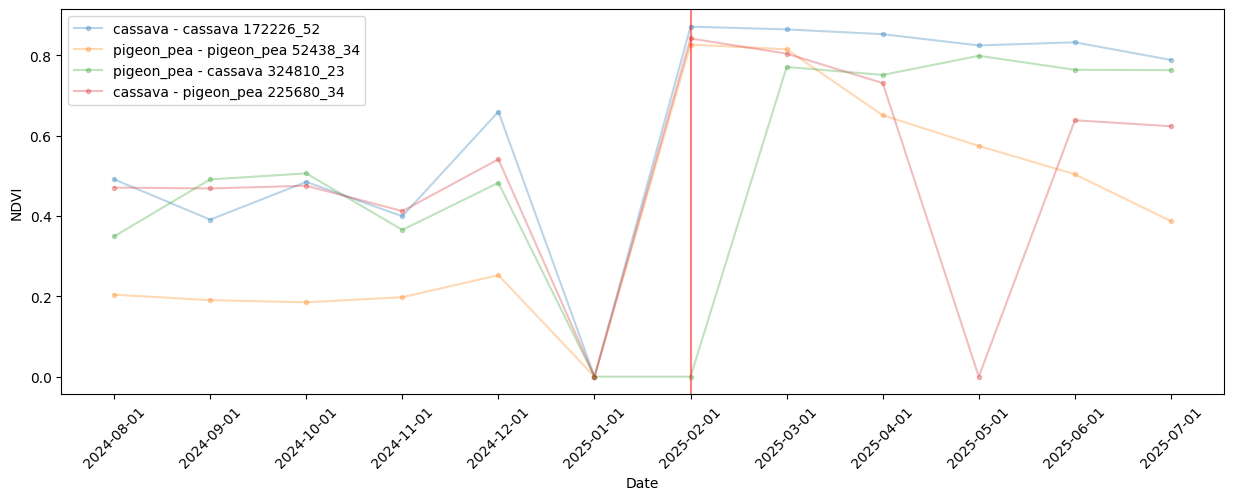

In [77]:
plot_ndvi_time_series(
    presto_formatted_df=results, 
    predictor ='catboost',
    id_ssus=ssus, 
)